# **Term Deposit Subscription Prediction**

Dataset: Bank Marketing Dataset (UCI ML Repository)

## **Problem Statement**

Banks run marketing campaigns to convince customers to subscribe to term deposits.
The goal is to predict whether a customer will subscribe (yes/no) based on demographic, financial, and campaign-related features.

This is a binary classification problem.

## STEP 1: Import Libraries

In [25]:
# Core libraries
import pandas as pd
import numpy as np

## STEP 2: Load the Dataset

In [26]:
df = pd.read_csv("/content/drive/MyDrive/bank-full.csv", sep=";")
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## STEP 3: Dataset Exploration

In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [28]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


The dataset contains both numerical and categorical variables with no missing values, making it suitable for supervised learning after proper encoding.

### Check Class Imbalance

In [29]:
# Target distribution
df['y'].value_counts()
# Percentage distribution
df['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


y is the target variable

### Visualize imbalance

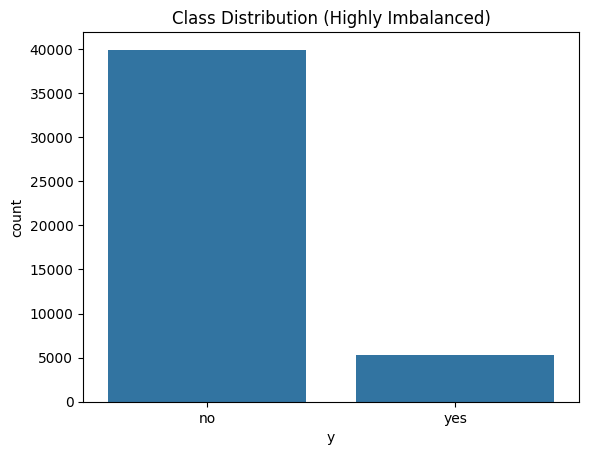

In [30]:
sns.countplot(x='y', data=df)
plt.title("Class Distribution (Highly Imbalanced)")
plt.show()

no ≫ yes

Only ~11% customers subscribe → imbalanced dataset

## STEP 4 : Separate Features & Target

In [31]:
X = df.drop("y", axis=1)
y = df["y"].map({"yes": 1, "no": 0})


## STEP 5: Preprocessing (Encoding + Scaling)

In [32]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)


## STEP 6: Train–Test Split

In [33]:
 from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT
)


Stratified splitting ensures that the minority class is adequately represented in both training and testing sets.

## STEP 7:
## Random Forest (Balanced)

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model_bal = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=80,
        max_depth=12,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model_bal.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

Automatically gives more importance to minority class (yes)

## STEP 8:  Confusion Matrix (Heatmap)

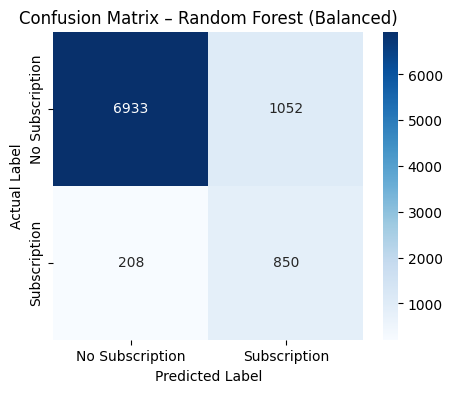

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = rf_model_bal.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Subscription", "Subscription"],
    yticklabels=["No Subscription", "Subscription"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix – Random Forest (Balanced)")
plt.show()


True Positives → correctly predicted subscribers

False Negatives → missed subscribers (very costly in marketing)

## STEP 9: Evaluation (Focus on F1, Recall)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf_model_bal.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.87      0.92      7985
           1       0.45      0.80      0.57      1058

    accuracy                           0.86      9043
   macro avg       0.71      0.84      0.75      9043
weighted avg       0.91      0.86      0.88      9043



The model achieves high recall for the minority class, making it suitable for marketing campaigns where identifying potential subscribers is critical.

## STEP 10: ROC Curve (Imbalance-Safe Metric)

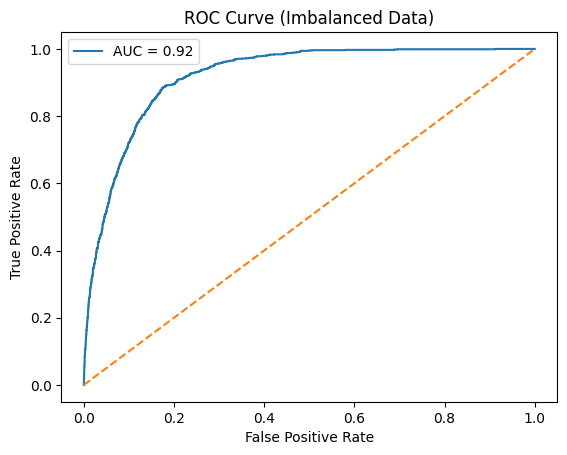

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf_model_bal.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Imbalanced Data)")
plt.legend()
plt.show()


The ROC curve demonstrates strong discriminatory power, confirming the model’s ability to distinguish between subscribers and non-subscribers.

## STEP 11: Lime – Model Explainability

In [16]:
!pip install lime


In [17]:
import lime
import lime.lime_tabular


In [20]:
preprocessor = rf_model_bal.named_steps["prep"]


In [21]:
X_train_lime = preprocessor.transform(X_train).toarray()
X_test_lime  = preprocessor.transform(X_test).toarray()


In [22]:
feature_names = preprocessor.get_feature_names_out()


In [23]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names,
    class_names=["No", "Yes"],
    mode="classification",
    discretize_continuous=True
)


In [24]:
for i in range(5):
    exp = explainer.explain_instance(
        X_test_lime[i],
        rf_model_bal.named_steps["model"].predict_proba,
        num_features=10
    )
    print(f"\nExplanation for instance {i}")
    print(exp.as_list())



Explanation for instance 0
[('num__duration > 0.23', 0.30096011258038524), ('cat__poutcome_success <= 0.00', -0.10436285231651665), ('0.00 < cat__contact_unknown <= 1.00', -0.08393329916273717), ('cat__month_oct <= 0.00', -0.061677387444738996), ('cat__loan_yes > 0.00', -0.0518295695518142), ('0.00 < cat__month_may <= 1.00', -0.04877417327204913), ('0.00 < cat__housing_yes <= 1.00', -0.046019509124138054), ('cat__job_blue-collar > 0.00', -0.037843150820340905), ('-0.30 < num__balance <= 0.02', 0.036247332347633485), ('cat__month_nov <= 0.00', 0.035811697395416224)]

Explanation for instance 1
[('cat__poutcome_success <= 0.00', -0.09609289677188515), ('0.00 < cat__contact_unknown <= 1.00', -0.0858623084711023), ('cat__month_mar <= 0.00', -0.07071170004109527), ('cat__job_unknown <= 0.00', 0.06295626542098534), ('0.00 < cat__housing_yes <= 1.00', -0.05256227308173516), ('cat__month_oct <= 0.00', -0.05242460453059628), ('0.00 < cat__month_may <= 1.00', -0.05180517057319346), ('-0.30 < nu


- Call duration is the strongest predictor of subscription
- Previous successful campaigns significantly increase conversion probability
- Excessive campaign contacts reduce effectiveness


“I trained a balanced Random Forest classifier to predict term deposit subscription and explained its predictions using LIME.”